In [1]:
from collections import defaultdict
from io import BytesIO
from pathlib import Path

from PIL import Image
from tensorboard.backend.event_processing import event_accumulator


log_path = Path("/media/aris/Data/master2025dev/aris_master/training/03-27_4_class_default_conditioned/logs")
output_root = log_path / "extracted_images"
output_root.mkdir(parents=True, exist_ok=True)


def sanitize_name(name: str) -> str:
	return name.replace("/", "__").replace(" ", "_")


event_files = sorted(log_path.rglob("events.out.tfevents.*"))
print(f"Found {len(event_files)} event files under {log_path}")

written_files = []

for event_file in event_files:
	accumulator = event_accumulator.EventAccumulator(
		str(event_file),
		size_guidance={event_accumulator.IMAGES: 0},
	)
	accumulator.Reload()

	image_tags = accumulator.Tags().get("images", [])
	if not image_tags:
		continue

	run_output_root = output_root / event_file.parent.relative_to(log_path)
	for tag in image_tags:
		tag_output_dir = run_output_root / sanitize_name(tag)
		tag_output_dir.mkdir(parents=True, exist_ok=True)

		for index, image_event in enumerate(accumulator.Images(tag)):
			image = Image.open(BytesIO(image_event.encoded_image_string)).convert("RGB")
			output_file = tag_output_dir / f"step_{image_event.step:08d}_idx_{index:04d}.png"
			image.save(output_file)
			written_files.append(output_file)

print(f"Saved {len(written_files)} images to {output_root}")

Found 13 event files under /media/aris/Data/master2025dev/aris_master/training/03-27_4_class_default_conditioned/logs
Saved 237 images to /media/aris/Data/master2025dev/aris_master/training/03-27_4_class_default_conditioned/logs/extracted_images


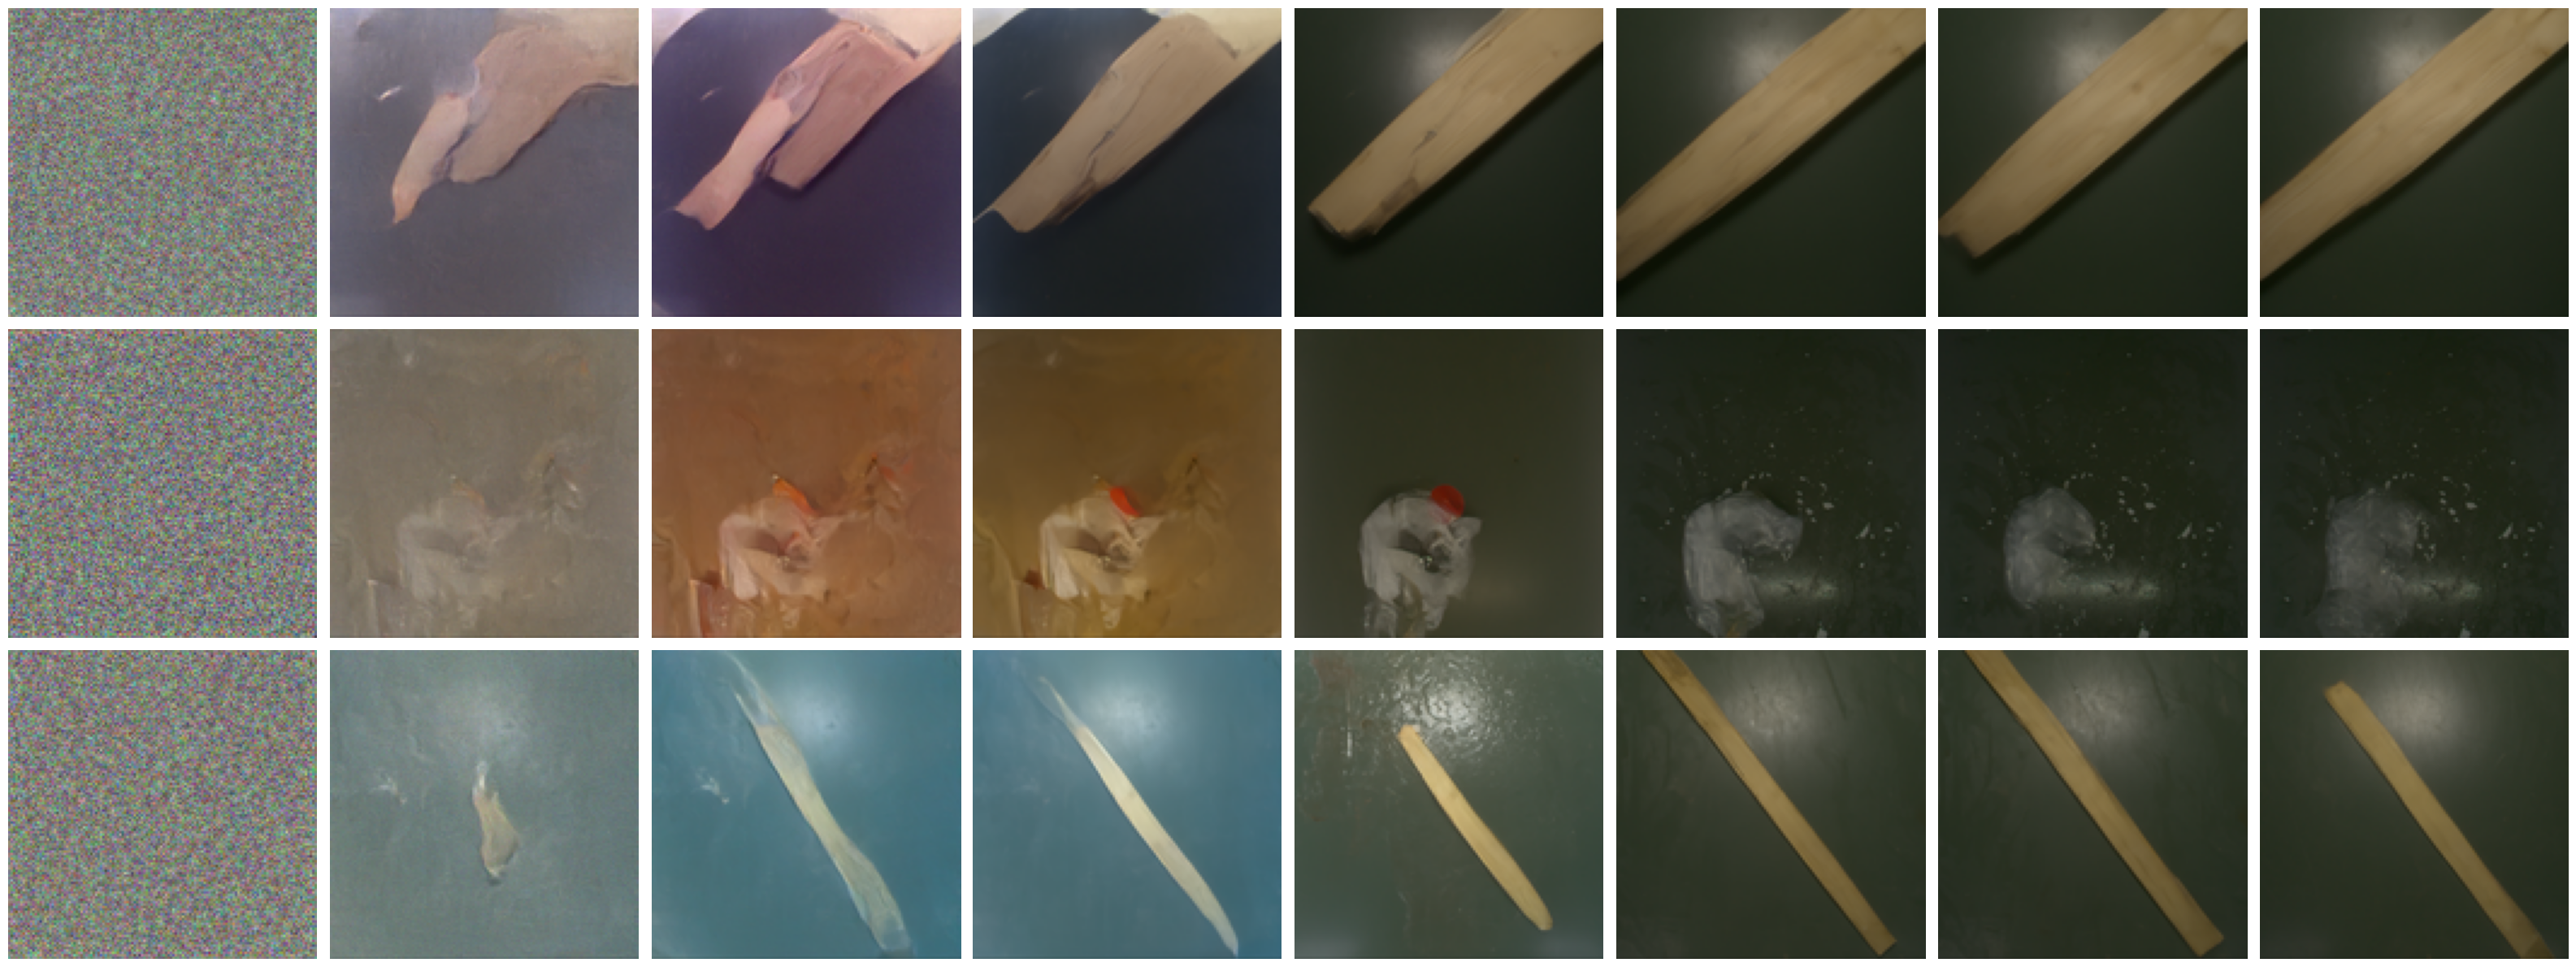

In [28]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


image_dir = output_root
image_paths = sorted(image_dir.rglob("*.png"))
selected_indices = [0, 1, 3, 10, 20, 50, 100, 200]

image_slices1 = []
image_slices2 = []
image_slices3 = []
slice_labels = []

for index in selected_indices:
	if index >= len(image_paths):
		continue

	image_path = image_paths[index]
	image_array = np.array(Image.open(image_path).convert("RGB"))
	image_slice1 = image_array[0:128, 640:768]
	image_slice2 = image_array[128:256, 640:768]
	image_slice3 = image_array[0:128, 0:128]

	image_slices1.append(image_slice1)
	image_slices2.append(image_slice2)
	image_slices3.append(image_slice3)
	slice_labels.append(f"{index}: {image_path.name}")


if image_slices1:
	figure, axes = plt.subplots(3, len(image_slices1), figsize=(4 * len(image_slices1), 3*4))
	if len(image_slices1) == 1:
		axes = [axes]

	for axis, image_slice, label in zip(axes[0], image_slices1, slice_labels):
		axis.imshow(image_slice)
		# axis.set_title(label, fontsize=9)
		axis.axis("off")
  
	for axis, image_slice, label in zip(axes[1], image_slices2, slice_labels):
		axis.imshow(image_slice)
		axis.axis("off")
	for axis, image_slice, label in zip(axes[2], image_slices3, slice_labels):
		axis.imshow(image_slice)
		axis.axis("off")
        

    # lower the spacing between subplots to make them more compact
	plt.subplots_adjust(wspace=0.01, hspace=0.1)
	plt.tight_layout()
	plt.show()
else:
	print(f"No PNG images found in {image_dir}")

mask_fierce-wolf_2025-01-13T11-21-02-452.pt


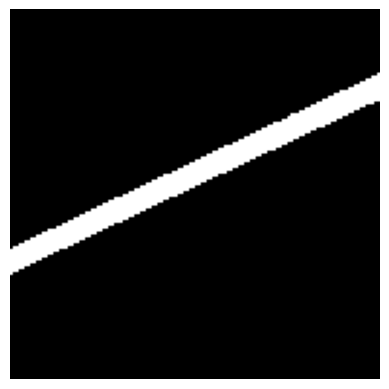

mask_fierce-wolf_2025-01-13T11-29-52-359.pt


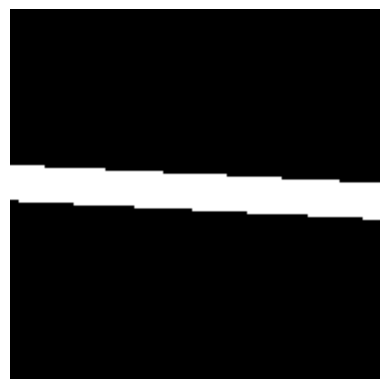

mask_fierce-wolf_2025-01-13T10-58-54-026.pt


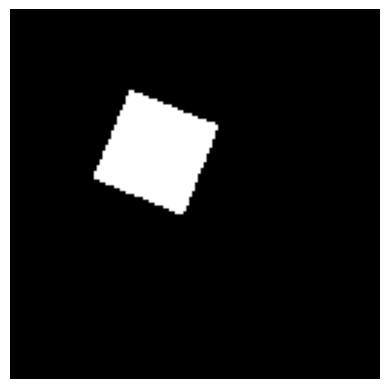

mask_fierce-wolf_2025-01-14T12-29-00-149.pt


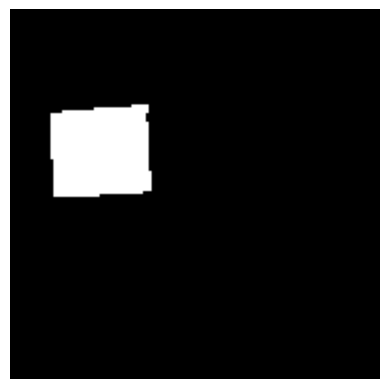

mask_fierce-wolf_2025-01-13T11-29-18-104.pt


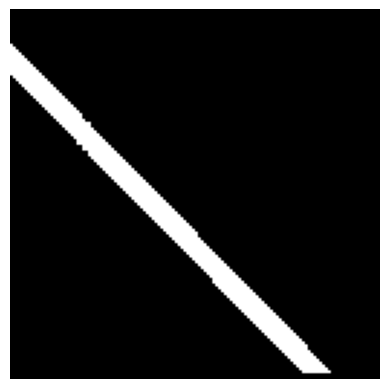

mask_fierce-wolf_2025-01-14T12-28-21-600.pt


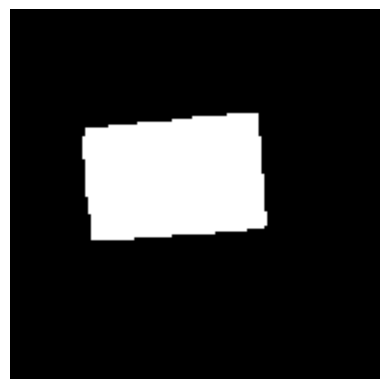

mask_bold-eagle_2024-11-04T16-47-23-026.pt


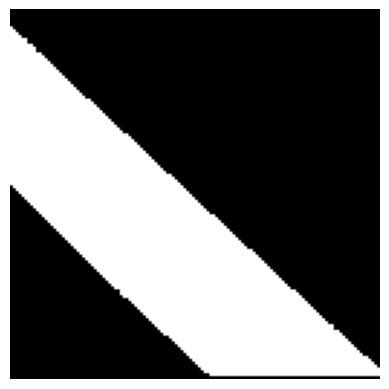

mask_fierce-wolf_2025-01-14T12-28-15-886.pt


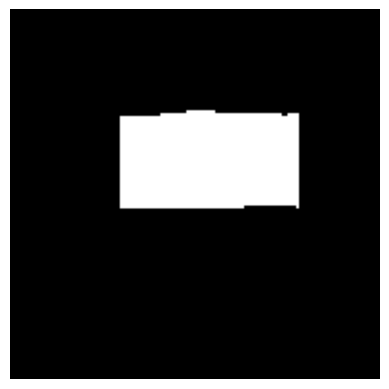

mask_fierce-wolf_2025-01-13T11-14-11-690.pt


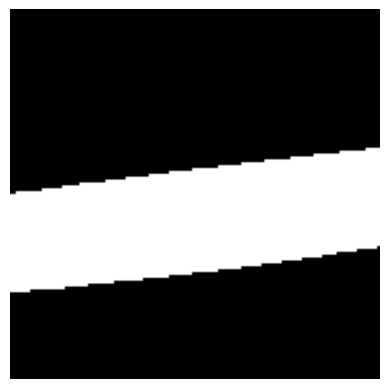

mask_bold-eagle_2024-11-04T16-47-02-003.pt


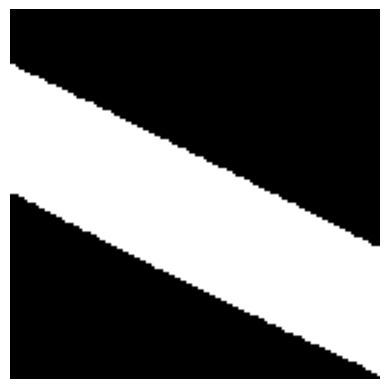

mask_fierce-wolf_2025-01-13T11-04-53-786.pt


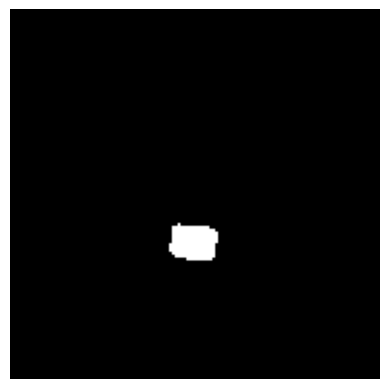

In [6]:
path = "/media/aris/Data/master2025dev/datasets/aris_4_class/1000_real/real/train/impregnated_wood/masks"

import os

import torch
import matplotlib.pyplot as plt

i = 0
for image_file in os.listdir(path):
    print(image_file)
    #load matrix and plot via matplotlib imshow. black and white image, so cmap='gray'
    matrix = torch.load(os.path.join(path, image_file))
    plt.imshow(matrix, cmap='gray')
    plt.axis('off')
    plt.show()
    if i>=10:
        break
    i+=1